In [5]:
import torch
import matplotlib.pyplot as plt
import numpy as np

from utils import ScaledFunctionWrapper
from botorch.test_functions.synthetic import Branin
func = ScaledFunctionWrapper(Branin())

In [6]:
import numpy as np
import warnings
warnings.filterwarnings('ignore', category=FutureWarning)
np.warnings = warnings


from simple_pfns4bo import PFNs4BO
import pfns4bo
from pfns4bo.scripts.tune_input_warping import fit_input_warping
import torch

methods = {}

methods['pfns4bo_hebo_plus'] = PFNs4BO(torch.load( pfns4bo.hebo_plus_model), bounds=func.bounds)

from simple_bayes_opt import BayesianOptimizer
methods['GP-UCB']  = BayesianOptimizer(bounds=func.bounds)


from simple_random_search import RandomSearch
methods['RS']  = RandomSearch(bounds=func.bounds)



In [7]:
bo_method = methods['pfns4bo_hebo_plus']

In [8]:


for _ in range(100):
    x = bo_method.suggest()
    y = func(x)
    bo_method.observe(x, y)
    print(f"Observed: x = {x}, y = {y}")


Observed: x = [0.67275238 0.42596369], y = 0.13259766924636487
Observed: x = [0.20928982 0.07884685], y = 0.24945263016742555
Observed: x = [0.46156205 0.8164673 ], y = 0.28204916210779246
Observed: x = [0.1955179 0.9982688], y = 0.10498640082052614
Observed: x = [0.94860909 0.27700354], y = 0.011943715006952939
Observed: x = [0.44784475 0.67873516], y = 0.17032967738083812
Observed: x = [0.0325605  0.00043113], y = 0.8617369625559549
Observed: x = [0.00451609 0.09937119], y = 0.8435759922049558
Observed: x = [0.00340663 0.0147708 ], y = 0.9865559582372947
Observed: x = [0.00300499 0.24542882], y = 0.6387861160983069
Observed: x = [0.00498951 0.97594204], y = 0.05714732308101622
Observed: x = [0.00887578 0.02838284], y = 0.9352091748116953
Observed: x = [0.81656288 0.99905876], y = 0.6819030128077028
Observed: x = [0.93903131 0.99703888], y = 0.5461551466401082
Observed: x = [0.00389227 0.03033737], y = 0.9578997075304035
Observed: x = [0.7796178  0.00512793], y = 0.06534935220583916
O

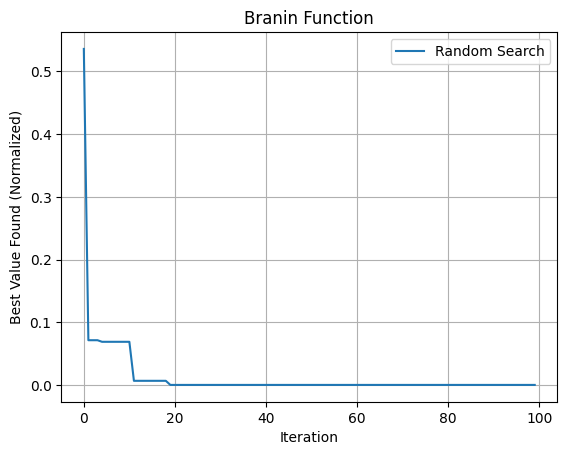

In [52]:
import matplotlib.pyplot as plt

X_rs, Y_rs = random_search(func, bounds, y_min, y_max)

def plot_best_so_far(Y, label):
    best = np.minimum.accumulate(Y.view(-1))
    plt.plot(best.numpy(), label=label)

plot_best_so_far(Y_rs, "Random Search")
plt.xlabel("Iteration")
plt.ylabel("Best Value Found (Normalized)")
plt.title("Branin Function")
plt.grid(True)
plt.legend()
plt.show()

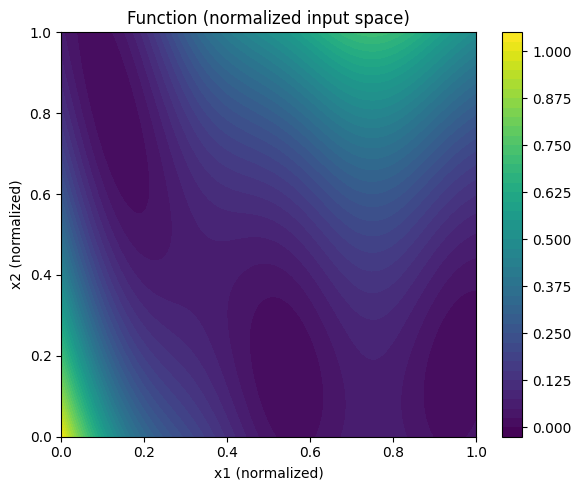

In [82]:

# Generate a grid of points in [0, 1] x [0, 1]
n_points = 100
x1 = np.linspace(0, 1, n_points)
x2 = np.linspace(0, 1, n_points)
X1, X2 = np.meshgrid(x1, x2)
X_grid = np.stack([X1.ravel(), X2.ravel()], axis=-1)
X_tensor = torch.tensor(X_grid, dtype=torch.float32)

# Evaluate the Branin function on the grid
Z = func(X_tensor).detach().numpy().reshape(n_points, n_points)

# Plot the function
plt.figure(figsize=(6, 5))
cp = plt.contourf(X1, X2, Z, levels=50, cmap='viridis')
plt.colorbar(cp)
plt.title("Function (normalized input space)")
plt.xlabel("x1 (normalized)")
plt.ylabel("x2 (normalized)")
plt.tight_layout()
plt.show()
